# Load QICK

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_4ce8cf0b4edf4470a598e5d1b1c2bc45@192.168.10.82:44717
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

# Qubit Setting

In [2]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

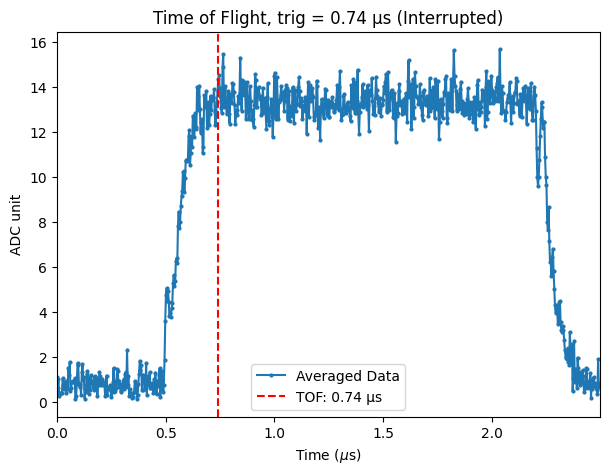

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0401\s001_tof_Q1_004


In [117]:
from qick_workspace.newscrip.s001_time_of_flight import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        # "res_freq_ge": 3400,
        "ro_length": 2.5,
        "res_length": 1.7,
        "res_gain_ge": 0.18,
        "res_ch": 0,
        "cheek_e": False,
        "check_f": True,
        "relax_delay": 100,
    }
)

tof = TOF(soc, soccfg, run_cfg)
tof.run(1000)
tof.saveLabber(qubit)


In [3]:
config_all.update("trig_time", 0.49, q_index=qubit)

# YOKO Setting

In [ ]:
# from qick_workspace.tools.YOKOGS200 import YOKOGS200
# import pyvisa

# rm = pyvisa.ResourceManager()
# yoko_connect = "USB0::0x0B21::0x0039::90ZB35281::INSTR"
# yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
# yoko.OutputOff()

## Current mode

In [8]:
# yoko.SetMode("current")
# yokocurrent = 1 * 1e-3
# yoko.SetCurrent(yokocurrent)
# yoko.GetValue()

## Voltage mode

In [ ]:
# yoko.SetMode("voltage")
# yoko_value = -12.6
# yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# print(yoko.GetValue())
# yoko_value = yoko.GetValue()

# GE State

## Resonator OneTone

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.7222),
 'Qi': -2328,
 'Ql': 934,
 'absQc': 667,
 'κ(MHz)': np.float64(7.2)}


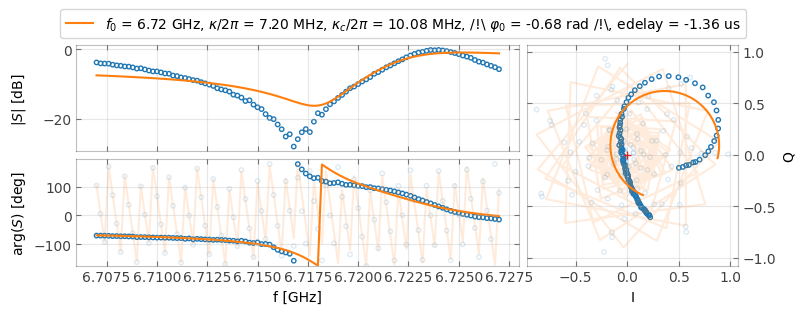

In [3]:
from qick_workspace.newscrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]


STEPS = 101

config_all.update("res.res_gain_ge", 0.05, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(soc, soccfg, run_cfg)
fres = onetone.run(py_avg=5, solve_type="hm")
## update value ##
config_all.update("res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

In [4]:
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s002_onetone_ge_Q1_001


## OneTone PunchOut

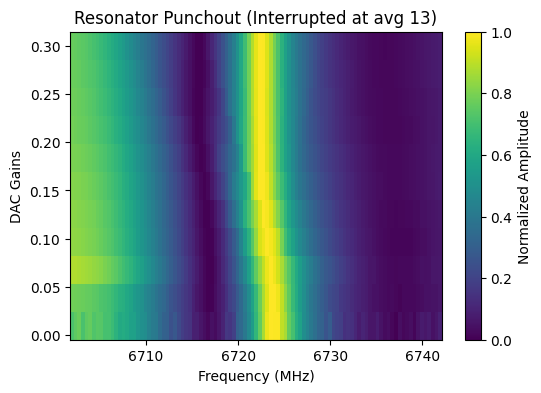

Experiment interrupted at 13 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s002b_res_ge_punchout_Q1_001


In [22]:
from qick_workspace.newscrip.s002b_res_punchout_ge import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]



STEPS_freq = 101

START_gain = 0.01
STOP_gain = 0.3
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
        ("relax_delay", 0),
    ]
)
punchout = Punchout(soc, soccfg, run_cfg)
punchout.run(py_avg=100, show_final_plot=True)
punchout.saveLabber(qubit, config_all=config_all)

## Qubit Spectrum ge

Experiment interrupted at 5 averages. Fit is based on partial data.


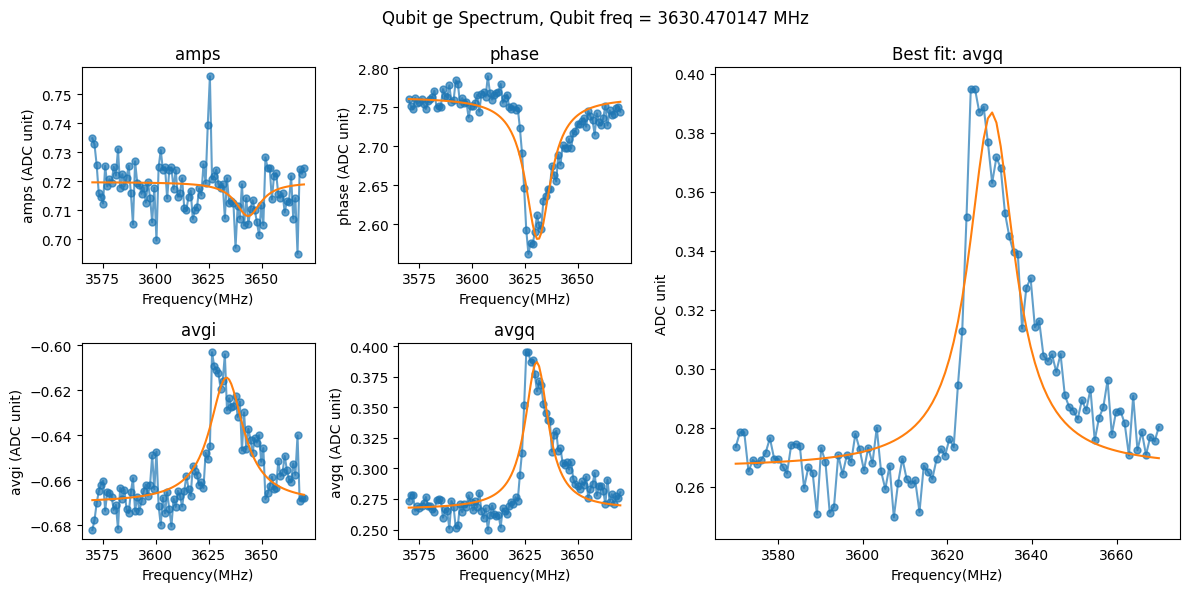

In [4]:
from qick_workspace.newscrip.s003_qubit_spec_ge import QubitSpec

center = 3620
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.1),
        ("qb_flat_top_length_ge", 5),
        ("relax_delay", 1),
        ("nqz_qb", 2),
    ]
)

spectrum_ge = QubitSpec(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(5)
config_all.update("qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb_mixer", f_ge, q_index=qubit)

In [237]:
spectrum_ge.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s003_qubit_spec_ge_Q2_003


### Fast flux spectrum

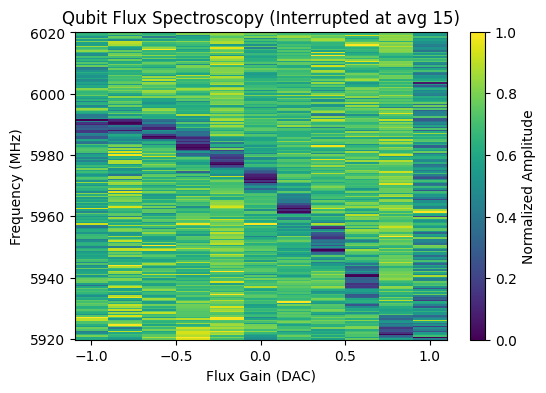

Experiment interrupted at 15 averages. Fit is based on partial data.


In [ ]:
from qick_workspace.newscrip.s003a_qubit_flux_spec_ge import QubitSpecFlux

center = 5970
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201

START_GAIN = -1
STOP_GAIN = 1
STEPS_GAIN = 11

config_all.update("qb_ch", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.3),
        ("qb_flat_top_length_ge", 0.5),
        ("relax_delay", 1),
        ("nqz_qb", 2),
        ("res_length", 3),
        ("ro_length", 2.478),
        ("res_gain_ge", 0.95),
        ###################
        ("flux_ch", 15),
        ("flux_gain", QickSweep1D("fluxloop", START_GAIN, STOP_GAIN)),
        ("steps_flux", STEPS_GAIN),
        ("flux_length", 0.7),
    ]
)

spectrumff_ge = QubitSpecFlux(soc, soccfg, run_cfg)
spectrumff_ge.run(500, swap_xy=True, show_final_plot=True)


## Time Rabi ge

Experiment interrupted at 33 averages. Fit is based on partial data.


(np.float64(0.006415584088129531), np.float64(0.0019565014963671733))

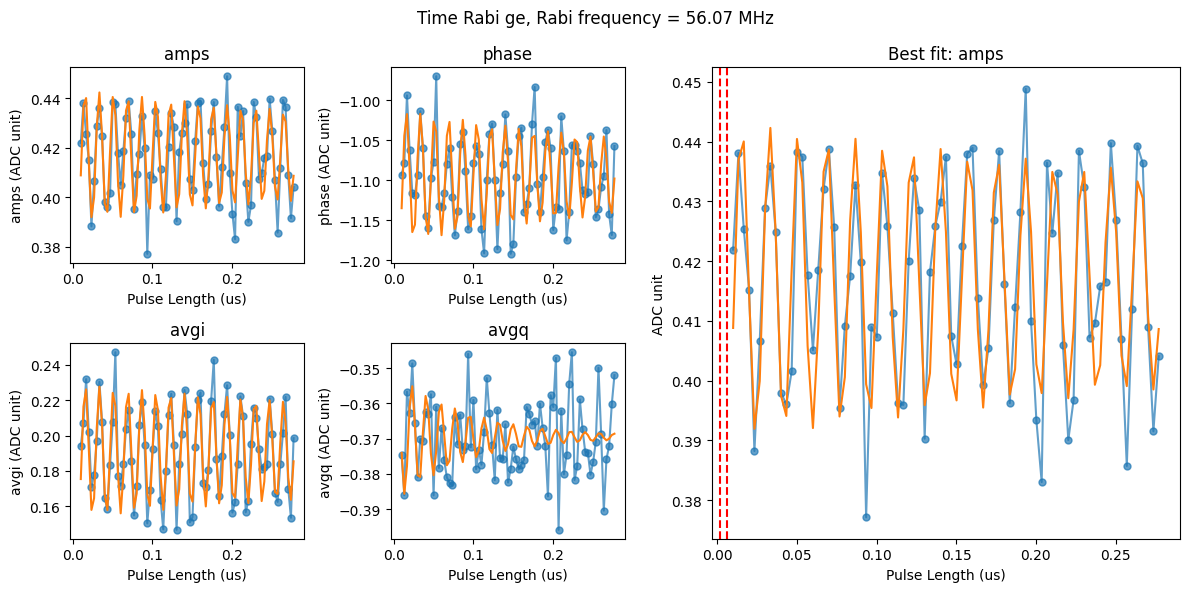

In [ ]:
from qick_workspace.newscrip.s004_time_rabi_ge import TimeRabi


config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.5),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.3)),
        ("steps", 81),
    ]
)

Trabi = TimeRabi(soc, soccfg, run_cfg)
Trabi.run(100)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ge

Experiment interrupted at 4 averages. Fit is based on partial data.


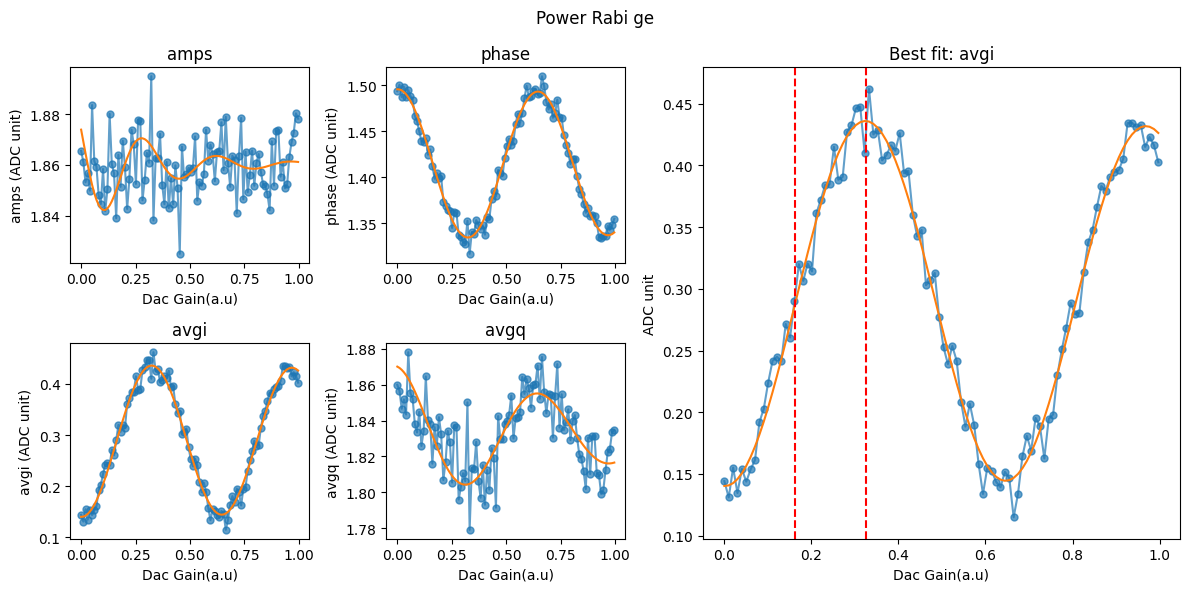

In [ ]:
from qick_workspace.newscrip.s005_power_rabi_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("nqz_qb", 2, q_index=qubit)
config_all.update("relax_delay", 200, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("pulse_type", "drag"),
        # ("qb_flat_top_length_ge", 0.1),
    ]
)

prabi = PowerRabi(soc, soccfg, run_cfg)
# prabi.IQ_PROCESS ='real'
pi_gain, pi2_gain = prabi.run(5)
config_all.update("pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("pi2_gain_ge", pi2_gain, q_index=qubit)

In [256]:
prabi.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s005_power_rabi_ge_Q3_004


## Amplified Amplitude Error (AAE)


[PowerRabi] Optimal pi gain = 0.311573


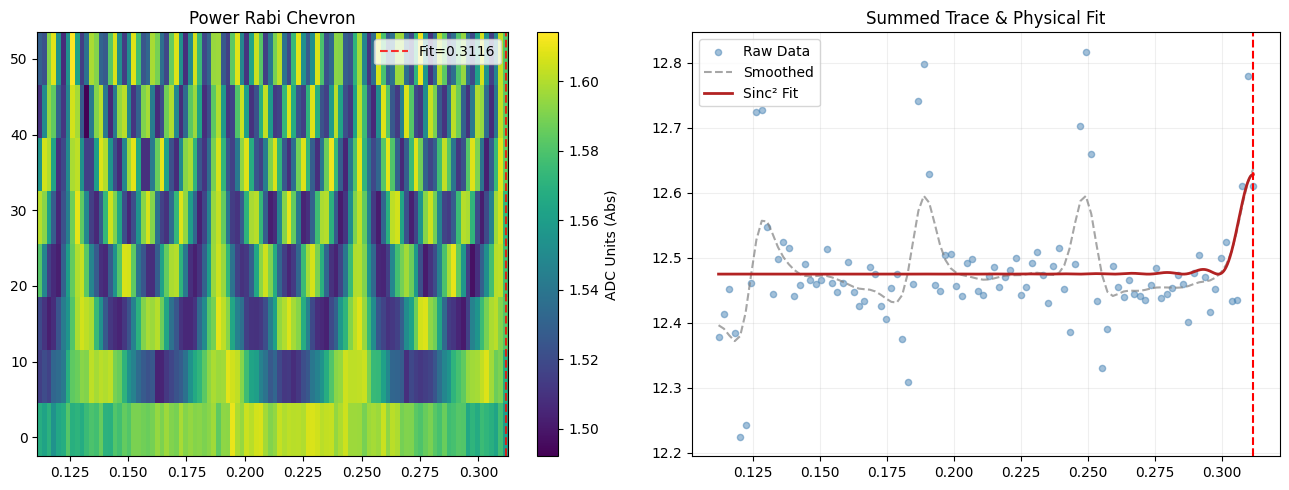

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0407\s005_power_rabi_chevron_Q1_008


In [151]:
from qick_workspace.newscrip.s005a_AAE import PowerRabiChevron

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
focus = run_cfg['pi_gain_ge']
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", focus-0.1, focus+0.1)),
        ("pulse_type", "drag"),
        ("iter_start", 1),
        ("iter_stop", 50),
        ("iter_step", 7),
        # ("qb_flat_top_length_ge", 0.1),

    ]
)

prabichevron = PowerRabiChevron(soc, soccfg, run_cfg)
result = prabichevron.run(10)
config_all.update("pi_gain_ge", result, q_index=qubit)
config_all.update("pi2_gain_ge", result / 2, q_index=qubit)
prabichevron.saveLabber(qubit, config_all=config_all)

## Ramsey ge

Experiment interrupted at 2 averages. Fit is based on partial data.


(array([6.70143925e-02, 5.29225820e+00, 4.89891997e+01, 1.92825127e+03,
        3.27710808e-01]),
 array([3.85385296e-03, 7.97611296e-03, 3.19411598e+00, 1.90415453e+05,
        1.28919671e-03]))

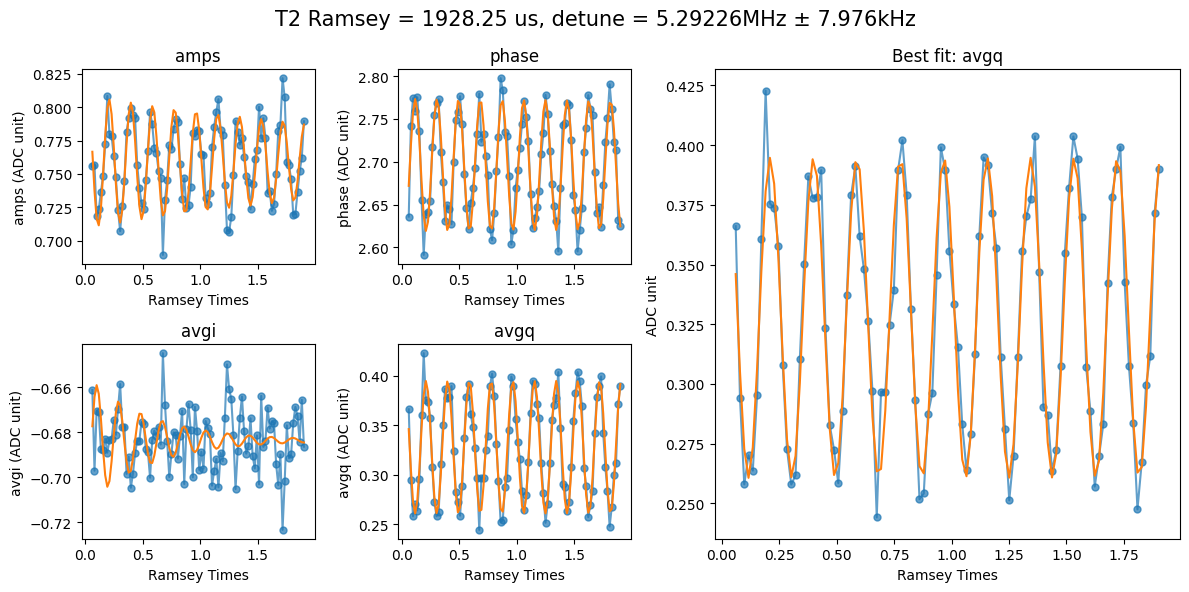

In [6]:
from qick_workspace.newscrip.s006_Ramsey_ge import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2 # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq",2),
        # ("pulse_type", "drag"),
    ]
)

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(20)

In [7]:
config_all.update("qb_freq_ge", t2r.correct_detune(), qubit)

over detune 3.29226MHz


In [243]:
t2r.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s006_Ramsey_ge_Q2_001


In [96]:
from qick_workspace.newscrip.s010_cryoscope import Cryoscope, CryoscopeProgram

TAU_START = 0.01  # us
TAU_STOP = 0.2  # us


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", 81),
        ("flux_length", QickSweep1D("tloop", TAU_START, TAU_STOP)),
        ("flux_gain", 0.1),
        ("flux_ch", 15),
        ("relax_delay", 20),
    ]
)

prog = CryoscopeProgram(
    soccfg, reps=100, final_delay=run_cfg["relax_delay"], cfg=run_cfg
)
result1 = prog.acquire(soc, rounds=30)


run_cfg["flux_gain"] = 0.5
prog = CryoscopeProgram(
    soccfg, reps=100, final_delay=run_cfg["relax_delay"], cfg=run_cfg
)
result2 = prog.acquire(soc, rounds=20)

run_cfg["flux_gain"] = 1
prog = CryoscopeProgram(
    soccfg, reps=100, final_delay=run_cfg["relax_delay"], cfg=run_cfg
)
result3 = prog.acquire(soc, rounds=20)


# result = Cryoscope.run_xy(soc, soccfg, run_cfg, py_avg=50)
flux_len = prog.get_pulse_param("flux_pulse", "length", as_array=True)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_26448\3873301117.py", line 1, in <module>
    from qick_workspace.newscrip.s010_cryoscope import Cryoscope, CryoscopeProgram
ModuleNotFoundError: No module named 'qick_workspace.newscrip.s010_cryoscope'


c:\Users\QEL\anaconda3\envs\qick2env\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\QEL\anaconda3\envs\qick2env\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Detuning')

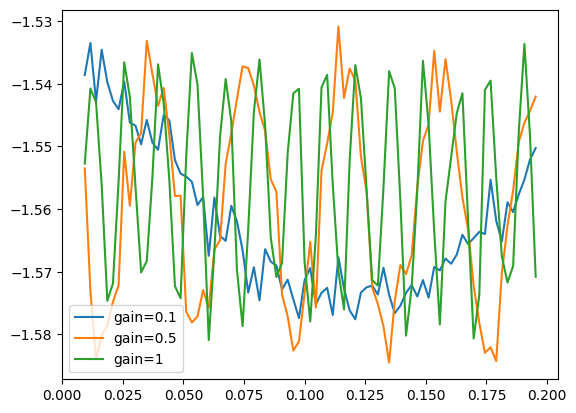

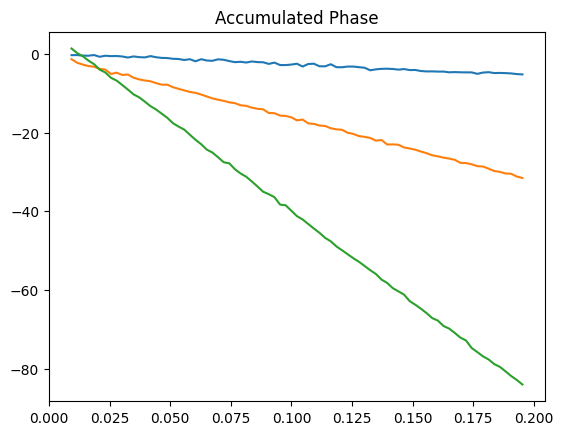

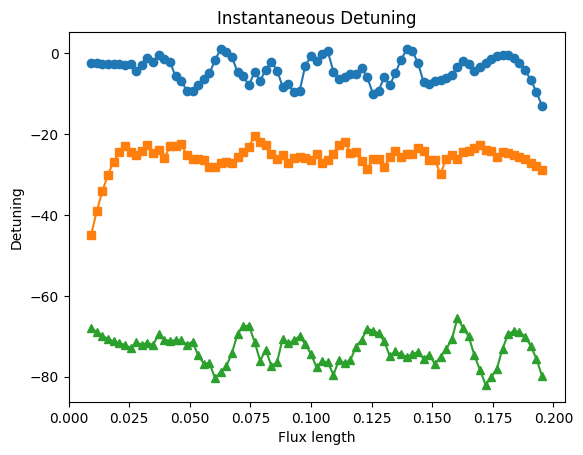

In [ ]:
X1 = result1[0][0].dot([1, 1j])
Y1 = result1[0][1].dot([1, 1j])
X2 = result2[0][0].dot([1, 1j])
Y2 = result2[0][1].dot([1, 1j])
X3 = result3[0][0].dot([1, 1j])
Y3 = result3[0][1].dot([1, 1j])

plt.plot(flux_len, X1, label="gain=0.1")
plt.plot(flux_len, X2, label="gain=0.5")
plt.plot(flux_len, X3, label="gain=1")
plt.legend()

X_centered1 = X1 - np.mean(X1)
Y_centered1 = Y1 - np.mean(Y1)
R1 = np.sqrt(X_centered1**2 + Y_centered1**2)
R1[R1 < 1e-6] = 1e-6
X_norm1 = X_centered1 / R1
Y_norm1 = Y_centered1 / R1
S1 = X_norm1 + 1j * Y_norm1
phase1 = np.unwrap(np.angle(S1))

X_centered2 = X2 - np.mean(X2)
Y_centered2 = Y2 - np.mean(Y2)
R2 = np.sqrt(X_centered2**2 + Y_centered2**2)
R2[R2 < 1e-6] = 1e-6
X_norm2 = X_centered2 / R2
Y_norm2 = Y_centered2 / R2
S2 = X_norm2 + 1j * Y_norm2
phase2 = np.unwrap(np.angle(S2))

X_centered3 = X3 - np.mean(X3)
Y_centered3 = Y3 - np.mean(Y3)
R3 = np.sqrt(X_centered3**2 + Y_centered3**2)
R3[R3 < 1e-6] = 1e-6
X_norm3 = X_centered3 / R3
Y_norm3 = Y_centered3 / R3
S3 = X_norm3 + 1j * Y_norm3
phase3 = np.unwrap(np.angle(S3))


plt.figure()
plt.plot(flux_len, phase1, label="gain=0.1")
plt.plot(flux_len, phase2, label="gain=0.5")
plt.plot(flux_len, phase3, label="gain=1")
plt.title("Accumulated Phase")


from scipy.signal import savgol_filter

dt = flux_len[1] - flux_len[0]

window_length = 13
polyorder = 3

phase_deriv1 = savgol_filter(phase1, window_length, polyorder, deriv=1)
freq1 = phase_deriv1 / dt / (2 * np.pi)

phase_deriv2 = savgol_filter(phase2, window_length, polyorder, deriv=1)
freq2 = phase_deriv2 / dt / (2 * np.pi)

phase_deriv3 = savgol_filter(phase3, window_length, polyorder, deriv=1)
freq3 = phase_deriv3 / dt / (2 * np.pi)

plt.figure()
plt.plot(flux_len, freq1, label="gain=0.1", marker="o")
plt.plot(flux_len, freq2, label="gain=0.5", marker="s")
plt.plot(flux_len, freq3, label="gain=1", marker="^")
plt.title("Instantaneous Detuning")
plt.xlabel("Flux length")
plt.ylabel("Detuning")

  0%|          | 0/50 [00:00<?, ?it/s]

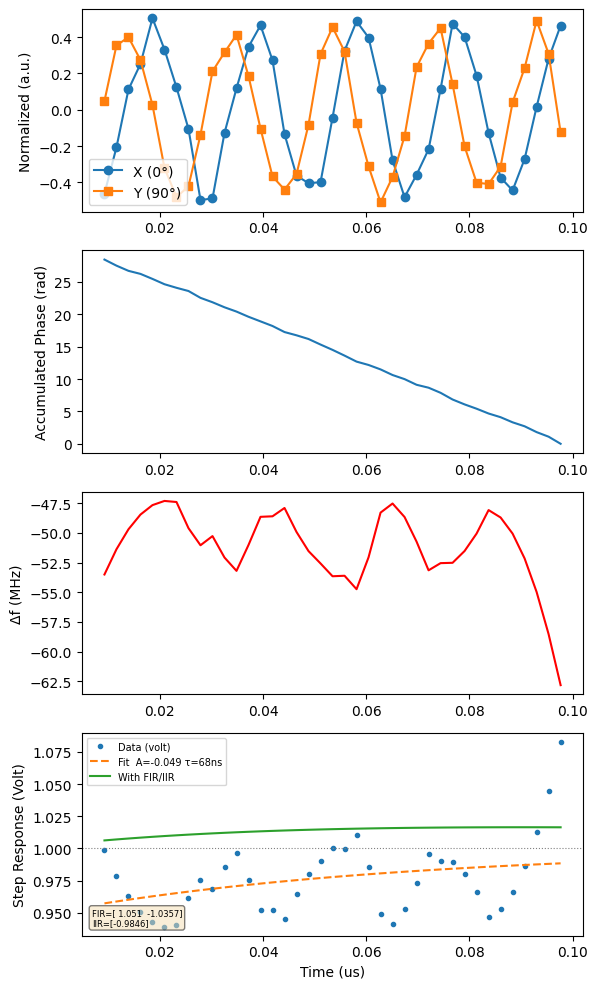

{'detuning': array([-53.50636094, -51.38147975, -49.69973682, -48.46113217,
        -47.66566577, -47.31333764, -47.40414778, -49.60710176,
        -51.04468609, -50.27397185, -52.0784764 , -53.19952236,
        -51.02046262, -48.65154615, -48.60735199, -47.90661776,
        -49.92728301, -51.53747939, -52.5764401 , -53.65401273,
        -53.61223423, -54.74421961, -52.05931648, -48.29677894,
        -47.53081   , -48.66790376, -50.73945588, -53.15395968,
        -52.55059904, -52.52131454, -51.52918315, -50.06135095,
        -48.08403684, -48.70759133, -50.06422933, -52.15395085,
        -54.97675589, -58.53264444, -62.82161651]),
 'step_response_freq': array([0.99787847, 0.95825003, 0.926886  , 0.90378638, 0.88895116,
        0.88238034, 0.88407392, 0.92515839, 0.95196893, 0.93759533,
        0.97124882, 0.99215601, 0.95151717, 0.90733755, 0.90651334,
        0.89344484, 0.93112968, 0.96115938, 0.98053571, 1.00063213,
        0.99985297, 1.02096418, 0.9708915 , 0.90072124, 0.88643613

In [ ]:
from qick_workspace.newscrip.s010_cryoscope import Cryoscope, CryoscopeProgram

TAU_START = 0.01  # us
TAU_STOP = 0.1  # us


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", 39),
        ("flux_length", QickSweep1D("tloop", TAU_START, TAU_STOP)),
        ("flux_gain", 0.8),
        ("flux_ch", 15),
        ("relax_delay", 20),
    ]
)

prog = Cryoscope(soc, soccfg, run_cfg)
prog.run_xy(soc, soccfg, run_cfg, py_avg=50)


Cryoscope PS Sweep: 100%|██████████| 100/100 [00:57<00:00,  1.75it/s]


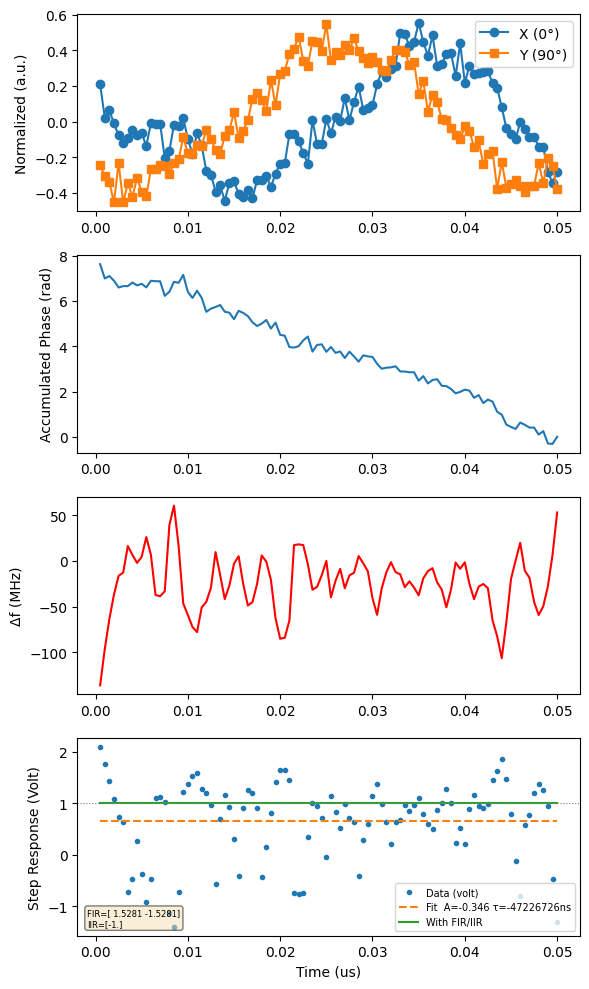

In [ ]:
from qick_workspace.newscrip.s010_cryoscope import Cryoscope


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("flux_gain", 1),
        ("flux_ch", 15),
        ("relax_delay", 30),
    ]
)
times_ps = np.linspace(0.0005, 0.05, 100)
results = Cryoscope.run_ps(soc, soccfg, run_cfg, py_avg=30, times_us=times_ps)


## Spin Echo ge

Experiment interrupted at 2 averages. Fit is based on partial data.


(array([ 5.92407227e-02,  8.35845455e-02,  2.22488101e+02,  4.48869978e+01,
        -6.21261518e-01]),
 array([1.35924878e-02, 1.24272053e-03, 1.40086433e+01, 1.52643338e+01,
        2.74481875e-03]))

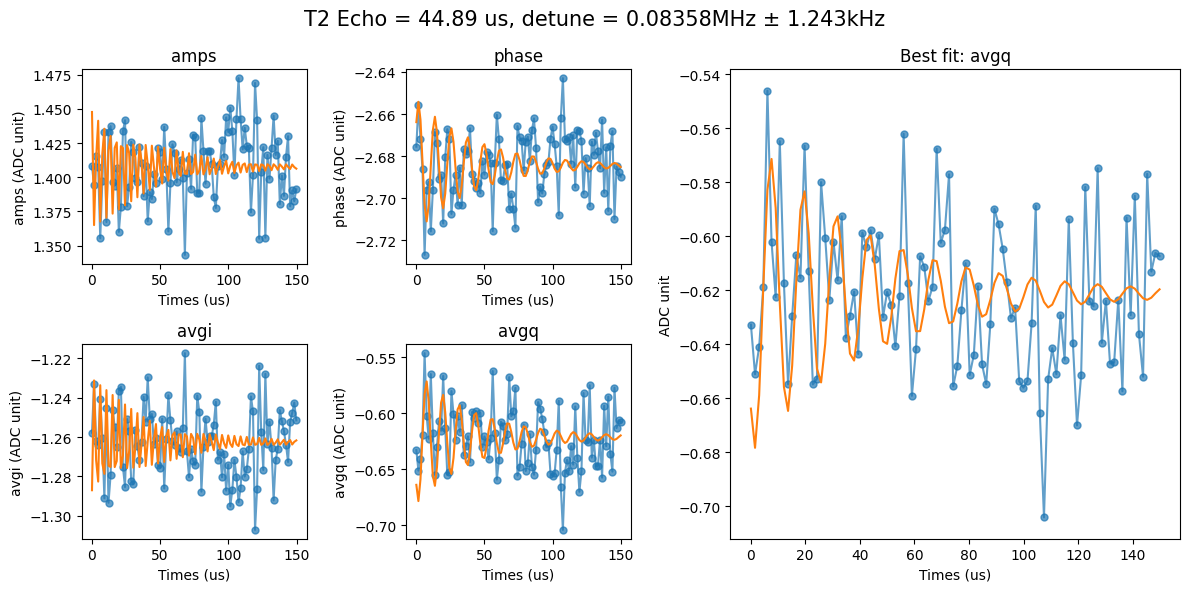

In [31]:
from qick_workspace.newscrip.s007_SpinEcho_ge import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 150  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 0.05),
        # ("pulse_type", "drag")
    ]
)

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(100)

In [112]:
t2e.saveLabber(qubit, config_all=config_all, title="10mK")

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s007_SpinEcho_ge_Q1_10mK_002


## T1 ge

Experiment interrupted at 4 averages. Fit is based on partial data.


(array([ 2.34819028,  0.44562165, 43.84010192]),
 array([0.00295163, 0.01238389, 2.1143973 ]))

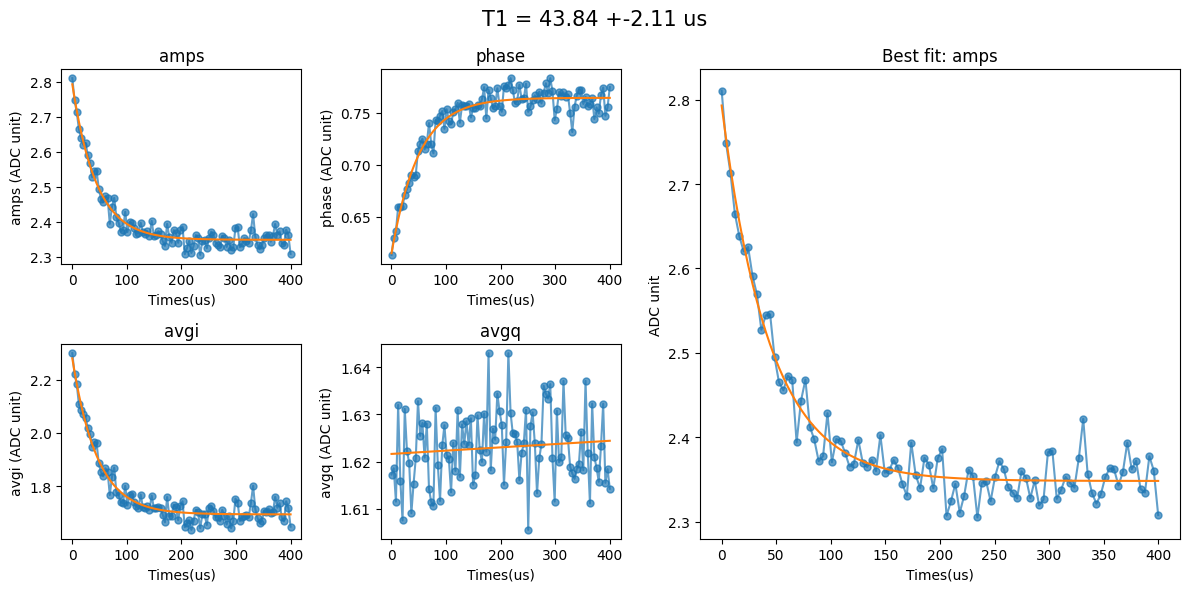

In [126]:
from qick_workspace.newscrip.s008_T1_ge import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 400  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        # ('pulse_type', "drag"),
    ]
)

t1 = T1(soc, soccfg, run_cfg)
t1.run(50)

In [ ]:
t1.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s008_T1_ge_Q1_10mK_004


In [4]:
from qick_workspace.newscrip.s008_T1_ge_ff import T1FastFlux

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 10  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 30),
        ### Flux Pulse ###
        ("steps_flux", 21),
        ("flux_length", 0.01 + QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("flux_gain", QickSweep1D("fluxloop", -1.0, 1.0)),
        ("flux_ch", 15),
    ]
)

t1 = T1FastFlux(soc, soccfg, run_cfg)
t1.run(30)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_12476\2585222871.py", line 1, in <module>
    from qick_workspace.newscrip.s008_T1_ge_ff import T1FastFlux
ModuleNotFoundError: No module named 'qick_workspace.newscrip.s008_T1_ge_ff'


In [ ]:
t1.saveLabber(qubit, config_all=config_all)

2026-03-25 14:24:33,689 - SR_Network:BlockingClient - Error: Socket operation timed out


Data saved to c:\Users\QEL\Desktop\SQC_soc\test\2026\03\Data_0325\s008_T1_ff_ge_Q1_001


## Single Shot

  0%|          | 0/5000 [00:00<?, ?it/s]

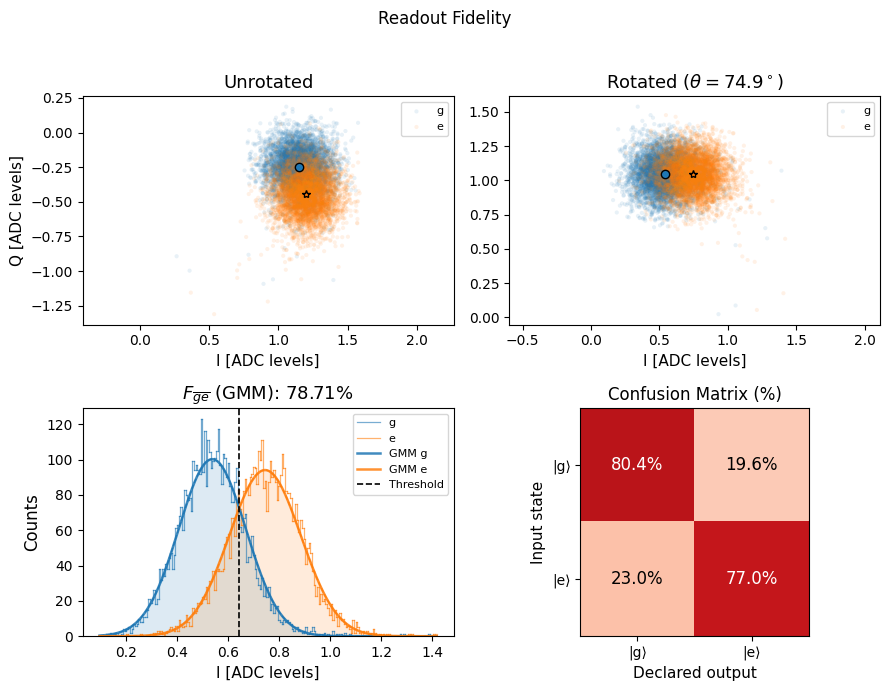

Rotation angle : 74.94 deg
GMM Fidelity   : 78.710%
  |g⟩  components=1  primary_mean=0.537  primary_std=0.132  secondary_weight=0.000
  |e⟩  components=1  primary_mean=0.744  primary_std=0.140  secondary_weight=0.000
Thresholds     : ['0.643']
Confusion Matrix (%):
 [[80.4 19.6]
 [23.  77. ]]
Current data file: D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0409\s000_singleshot_ge_Q1_017


In [65]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

### run single shot with optimized parameters ###
config_all.update('res_phase',0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update('res_phase', ssh_result[2], q_index=qubit)
ssh.saveLabber(qubit)

### ssh opt

Length loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Analyze AUC fidelity (ge):   0%|          | 0/4 [00:00<?, ?it/s]


--- Grid Search Result ---
Max fidelity (on grid): 0.8381
At length=4.000 us, gain=0.09250 DAC, freq=6721.38442 MHz

--- Interpolated Result ---
Max fidelity (interpolated): 0.8381
At length=4.000 us, gain=0.09173 DAC, freq=6721.38442 MHz


  0%|          | 0/5000 [00:00<?, ?it/s]

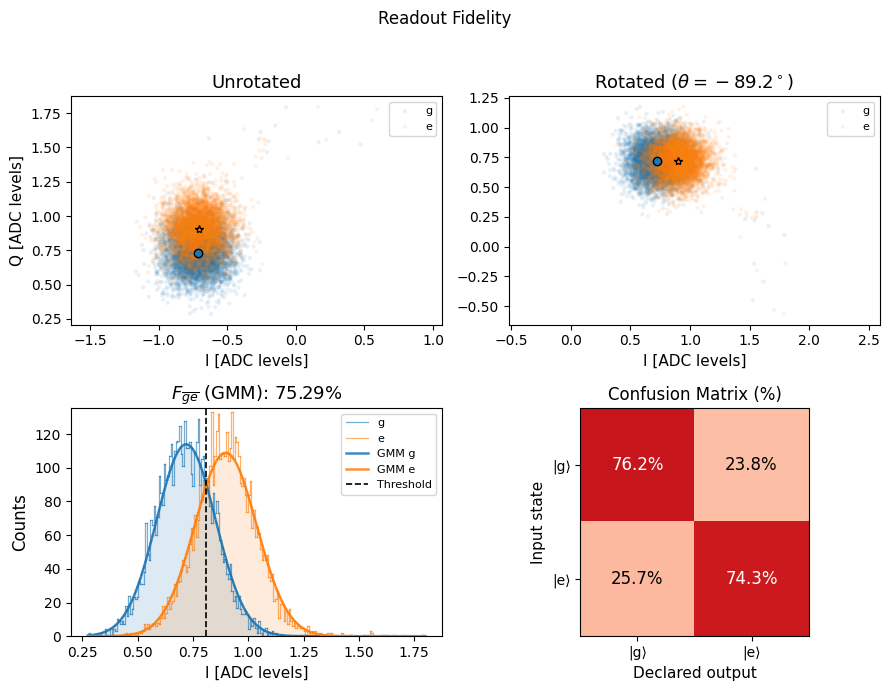

Rotation angle : -89.19 deg
GMM Fidelity   : 75.290%
  |g⟩  components=1  primary_mean=0.719  primary_std=0.133  secondary_weight=0.000
  |e⟩  components=1  primary_mean=0.898  primary_std=0.140  secondary_weight=0.000
Thresholds     : ['0.810']
Confusion Matrix (%):
 [[76.2 23.8]
 [25.7 74.3]]


In [54]:
from qick_workspace.newscrip.s000_SingleShot_opt import SingleShot_ge_opt

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"

freq_axis = np.linspace(run_cfg["res_freq_ge"] - 1, run_cfg["res_freq_ge"] + 8, 11)
gain_axis = np.linspace(0.07, 0.1, 5)
length_axis = np.linspace(2, 4, 4)
sweep_para = {"freq":run_cfg["res_freq_ge"] , "gain": gain_axis, "length": length_axis}


SHOT = 2000
ssh_opt = SingleShot_ge_opt(soc, soccfg, run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze()
config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)
config_all.update("res_freq_ge", freq, q_index=qubit)

### run single shot with optimized parameters ###
config_all.update('res_phase',0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update('res_phase', ssh_result[2], q_index=qubit)

# EF State

## Resonator OneTone ef

Experiment interrupted at 3 averages. Fit is based on partial data.


c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.8116),
 'Qi': -28546,
 'Ql': 1286,
 'absQc': 1231,
 'κ(MHz)': np.float64(5.3)}


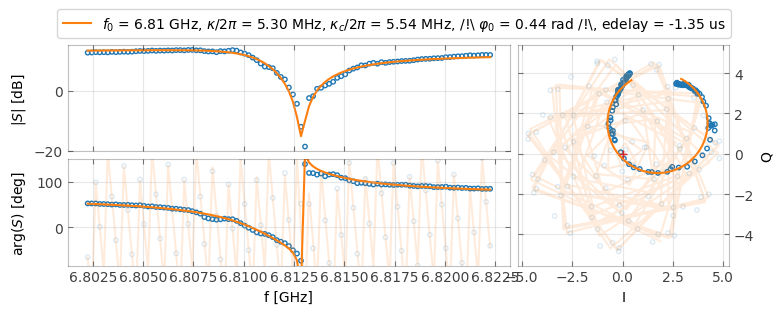

In [ ]:
from qick_workspace.newscrip.s009_res_spec_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),

    ]
)

onetone_ef = ResonatorSpec_ef(soc, soccfg, run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

Experiment interrupted at 2 averages. Fit is based on partial data.


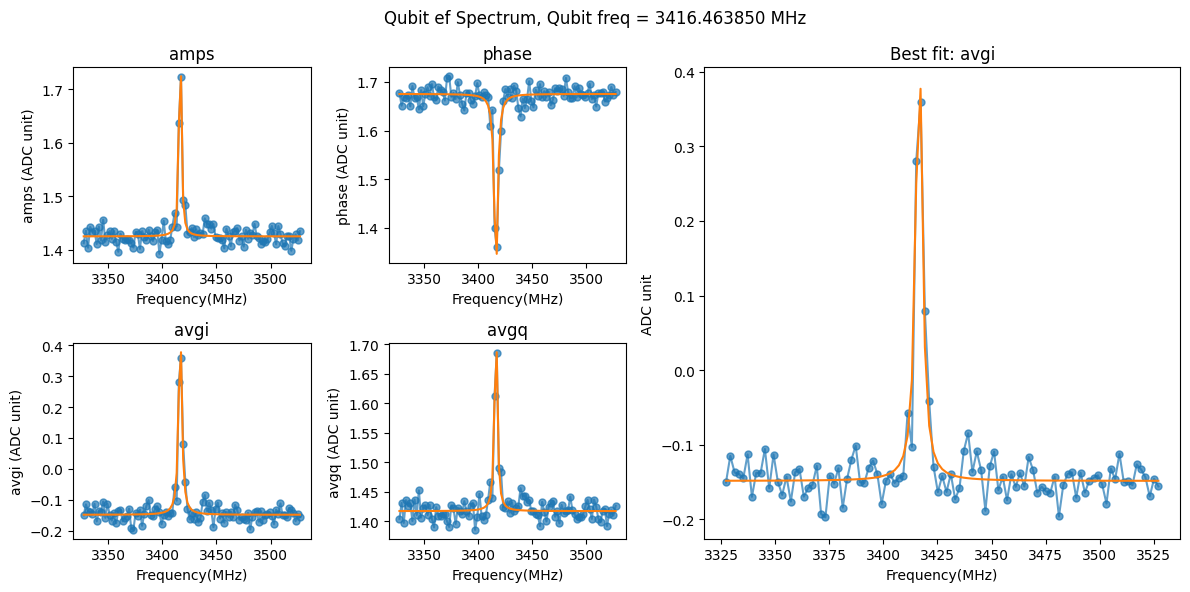

In [13]:
from qick_workspace.newscrip.s010_qubit_spec_ef import QubitSpec_ef

center = config_all.get_qubit(qubit)["qb_freq_ge"] - 200
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 101
config_all.update("qb_ch_ef", 0, q_index=qubit)
config_all.update("nqz_qb_ef", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.3),
        ("qb_flat_top_length_ef", 2),
        ("ge_ref", True),
    ]
)

spectrum_ef = QubitSpec_ef(soc, soccfg, run_cfg)
f_ef = spectrum_ef.run(10)
config_all.update("qb_freq_ef", f_ef, q_index=qubit)
config_all.update("qb_mixer_ef", f_ef, q_index=qubit)
# spectrum_ef.saveLabber(qubit, yoko_value=yoko_value)

In [120]:
spectrum_ef.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s010_qubit_spec_ef_Q1_001


## Power Rabi ef

Experiment interrupted at 3 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0409\s011_power_rabi_ef_Q1_011


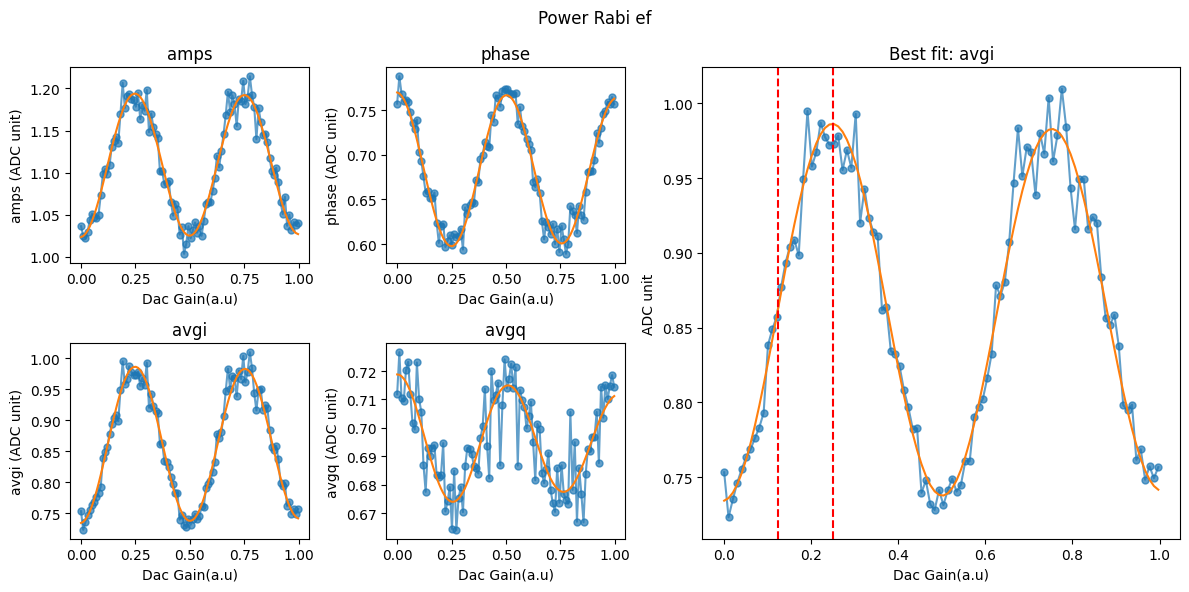

In [60]:
from qick_workspace.newscrip.s011_power_rabi_ef import PowerRabi_ef

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
    ]
)

prabi_ef = PowerRabi_ef(soc, soccfg, run_cfg)
pi_gain_ef, pi2_gain_ef = prabi_ef.run(50)
config_all.update("pi_gain_ef", pi_gain_ef, q_index=qubit)
config_all.update("pi2_gain_ef", pi2_gain_ef, q_index=qubit)
prabi_ef.saveLabber(qubit, config_all=config_all)

[Temp] A_meas=0.0278  A_ref=0.0342  ratio=1.2308
[Temp] Estimated temperature: 838.25 mK


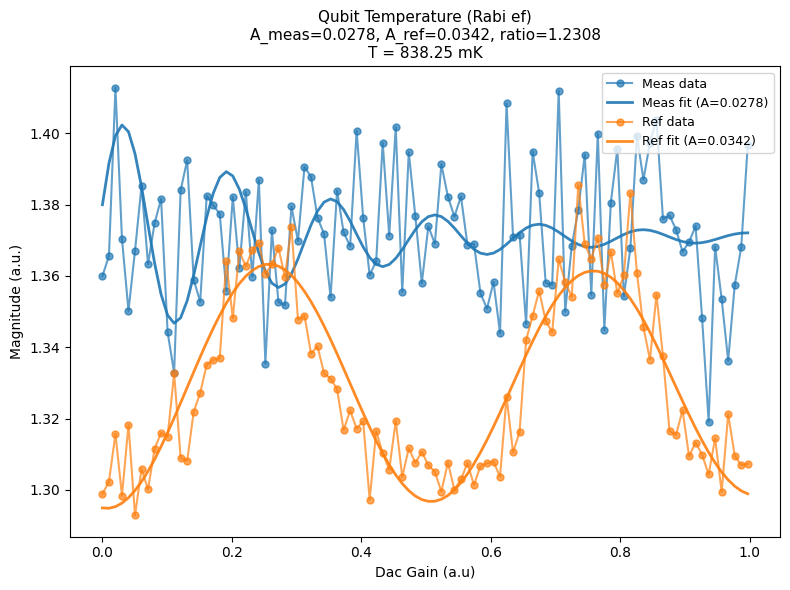

np.float64(0.8382483250165554)

In [55]:
from qick_workspace.newscrip.s013_qubit_temp import QubitTemperatureEf

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)
config_all.update("relax_delay", 100, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
        ("ro_length", 2),
    ]
)
rabi_temp = QubitTemperatureEf(soc, soccfg, run_cfg)
rabi_temp.run(5)

In [123]:
rabi_temp.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s013b_qubit_temp_ef_Q1_002


## Ramsey ef

Experiment interrupted at 3 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0409\s012_Ramsey_ef_Q1_009


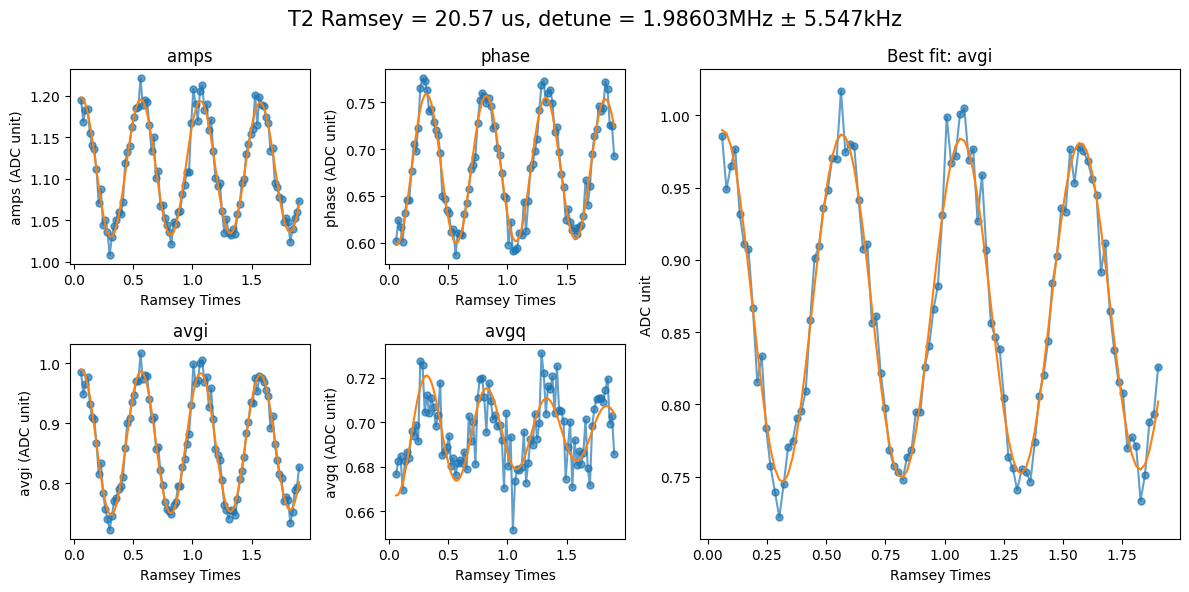

In [61]:
from qick_workspace.newscrip.s012_Ramsey_ef import Ramsey_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
        ("ge_ref", True),

    ]
)

t2r_ef = Ramsey_ef(soc, soccfg, run_cfg)
t2r_ef.run(100)
t2r_ef.saveLabber(qubit, config_all=config_all)

In [62]:
config_all.update("qb_freq_ef", t2r_ef.correct_detune(), qubit)

over detune -0.01397MHz


## T1 ef

Experiment interrupted at 4 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s013_T1_ef_Q3_001


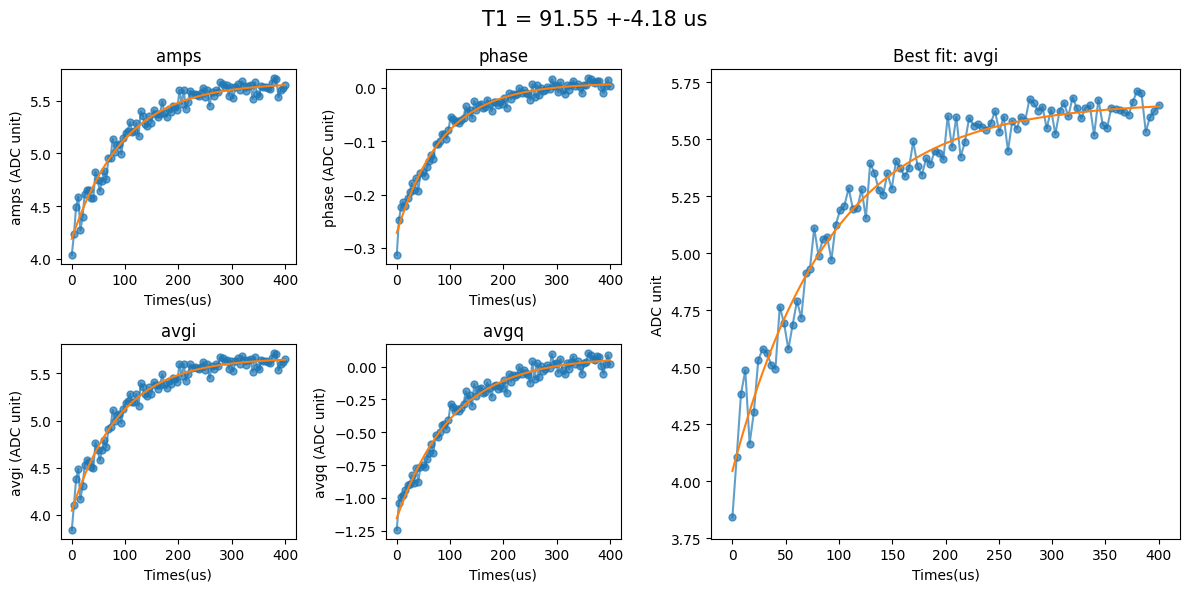

In [76]:
from qick_workspace.newscrip.s013_T1_ef import T1_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 400  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),

    ]
)

t1_ef = T1_ef(soc, soccfg, run_cfg)
t1_ef.run(50)
t1_ef.saveLabber(qubit, config_all=config_all)

## Single Shot gef

  0%|          | 0/5000 [00:00<?, ?it/s]

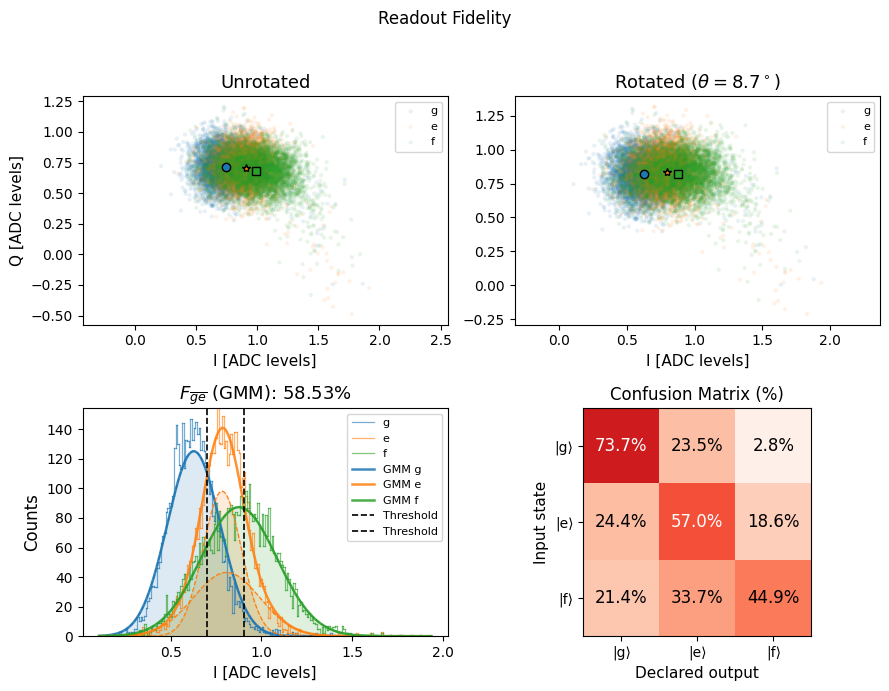

Rotation angle : 8.71 deg
GMM Fidelity   : 58.527%
  |g⟩  components=1  primary_mean=0.627  primary_std=0.146  secondary_weight=0.000
  |e⟩  components=2  primary_mean=0.783  primary_std=0.105  secondary_weight=0.433  ⚠ secondary component large — possible state leakage
  |f⟩  components=1  primary_mean=0.876  primary_std=0.209  secondary_weight=0.000
Thresholds     : ['0.701', '0.906']
Confusion Matrix (%):
 [[73.7 23.5  2.8]
 [24.4 57.  18.6]
 [21.4 33.7 44.9]]


[[0.5852666666666667],
 [0.7012181435222175, 0.9062275449623468],
 np.float64(8.71319070844505),
 array([[73.68, 23.48,  2.84],
        [24.4 , 57.  , 18.6 ],
        [21.42, 33.68, 44.9 ]])]

In [59]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = 'drag'

SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)

Length loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/3 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

...

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Analyze AUC fidelity (gef avg pairwise):   0%|          | 0/4 [00:00<?, ?it/s]


--- Grid Search Result ---
Max fidelity (on grid): 0.8868
At length=4.000 us, gain=0.07500 DAC, freq=6722.38442 MHz

Returning grid search result.


  0%|          | 0/5000 [00:00<?, ?it/s]

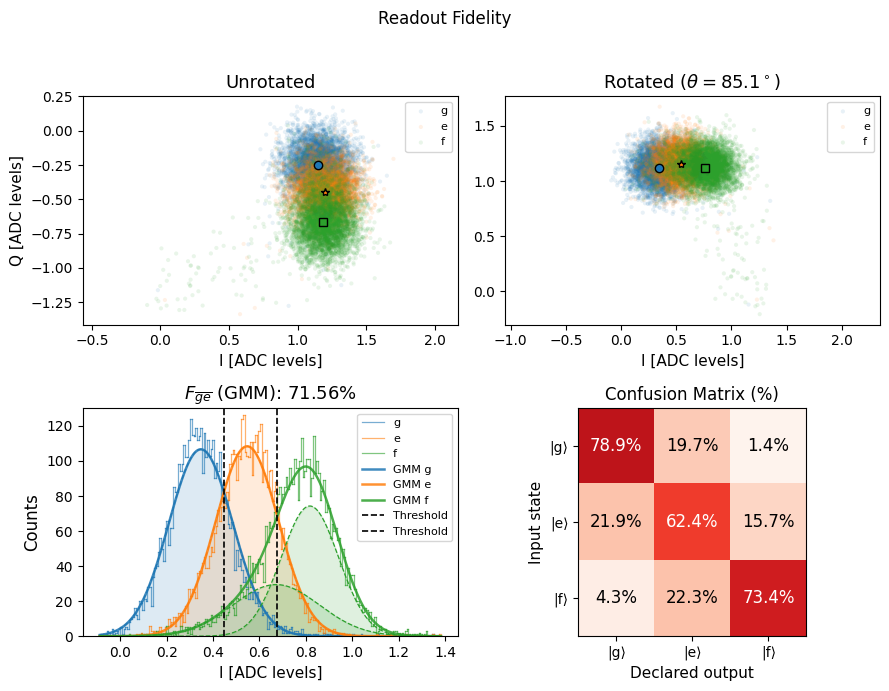

Rotation angle : 85.06 deg
GMM Fidelity   : 71.560%
  |g⟩  components=1  primary_mean=0.347  primary_std=0.138  secondary_weight=0.000
  |e⟩  components=1  primary_mean=0.547  primary_std=0.135  secondary_weight=0.000
  |f⟩  components=2  primary_mean=0.817  primary_std=0.124  secondary_weight=0.374  ⚠ secondary component large — possible state leakage
Thresholds     : ['0.446', '0.676']
Confusion Matrix (%):
 [[78.9 19.7  1.4]
 [21.9 62.4 15.7]
 [ 4.3 22.3 73.4]]


[[0.7155999999999999],
 [0.44618972797883893, 0.6764287993674554],
 np.float64(85.05918830180241),
 array([[78.92, 19.66,  1.42],
        [21.94, 62.4 , 15.66],
        [ 4.3 , 22.34, 73.36]])]

In [63]:
from qick_workspace.newscrip.s000_SingleShot_opt import SingleShot_ge_opt

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"

freq_axis = np.linspace(run_cfg["res_freq_ge"] - 1, run_cfg["res_freq_ge"] + 5, 4)
gain_axis = np.linspace(0.05, 0.1, 3)
length_axis = np.linspace(1, 4, 4)
sweep_para = {"freq":freq_axis, "gain": gain_axis, "length": length_axis}


SHOT = 1000
ssh_opt = SingleShot_ge_opt(soc, soccfg, run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para, shot_f=True)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze()
config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)
config_all.update("res_freq_ge", freq, q_index=qubit)

### run single shot with optimized parameters ###
config_all.update('res_phase',0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)


# AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

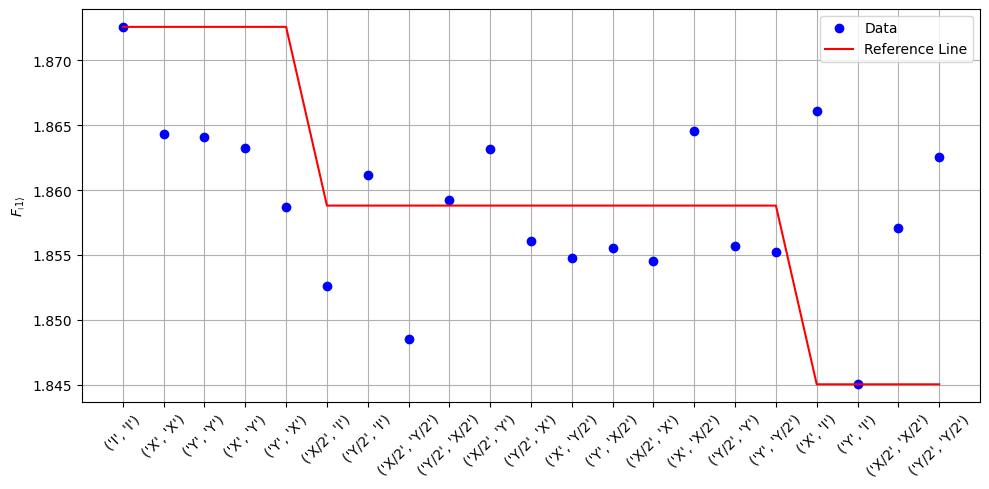

In [ ]:
from qick_workspace.newscrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)

run_cfg.update([
    # ("pulse_type", "drag"),
])
allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(10)
allxy.plot()

### Drag allxy

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

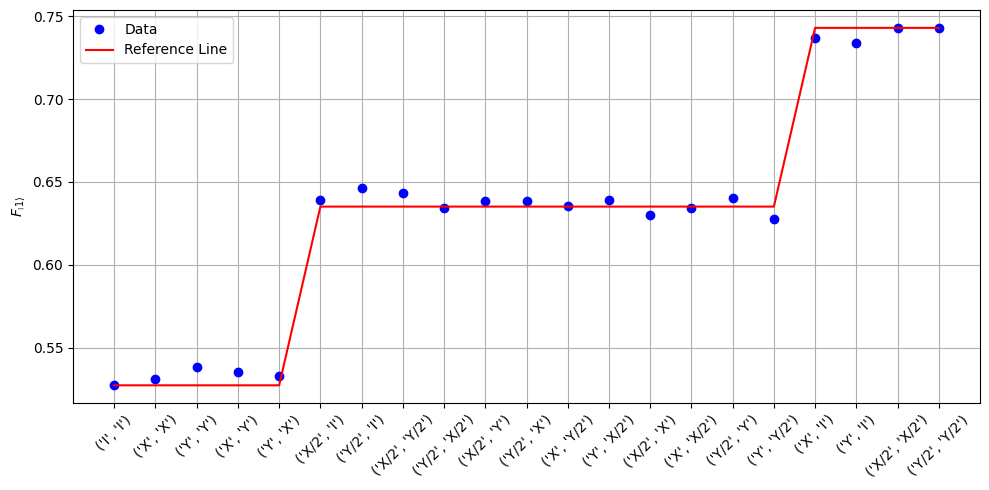

In [66]:
from qick_workspace.newscrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("pulse_type", "drag"),
])
allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(10, iq_process='real')
allxy.plot()

## State tomography 

In [ ]:
from qick_workspace.newscrip.s016_state_tomography import Tomography

pyavg = 5

run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(soc, soccfg, run_cfg)

tomo.run(py_avg=pyavg, prep_pulse_name="x180")

tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_34320\2920917739.py", line 9, in <module>
    tomo.run(py_avg=pyavg, prep_pulse_name="x180", iq_process='real')
TypeError: run() got an unexpected keyword argument 'iq_process'


# Randomized Benchmarking


=== Standard RB (Reference) ===


Standard RB:   0%|          | 0/12 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

[fitrb] p=0.999968  a=0.3782  b=0.2787
[fitrb] σ(p)=6.82e-02  σ(a)=8.09e+02  σ(b)=8.09e+02
  p        = 99.9968 ± 6.8163 %
  F_gate   = 100.2810 ± 3.4323 %
  EPC      = -0.2810 ± 3.4323 %


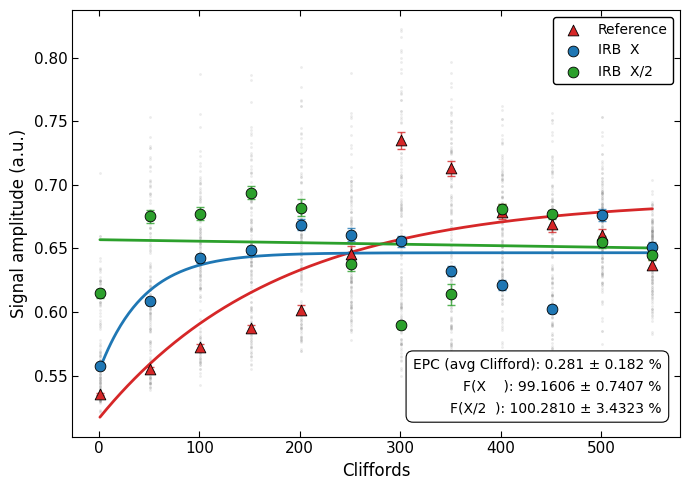

RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0409\s015_RB_Q1_ref_024
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0409\s015_RB_X_Q1_013
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0409\s015_RB_halfX_Q1_015
  AutoRB Summary
  Reference EPC : 0.2810 ± 0.1823 %
  p (decay)     : 99.4380 ± 0.3646 %

  Gate fidelities:
    X       F = 99.1606 ± 0.7407 %  (EPC = 0.8394 %)
    X/2     F = 100.2810 ± 3.4323 %  (EPC = -0.2810 %)


In [67]:
from qick_workspace.newscrip.s015_Auto_RB import AutoRB

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"

auto = AutoRB(soc, soccfg, run_cfg)
interleaved = ["X", "X/2"]
auto.run(
    py_avg=5,
    max_circuit_depth=600,
    delta_clifford=50,
    number_sample=50,
    interleaved_gates=interleaved,
    iq_process='real'
)
auto.plot()
auto.saveLabber(qubit, config_all=config_all)
print(auto.summary())


--- Running Standard RB (Ref) ---


Standard RB:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

[fitrb] p=0.970587  a=-0.1784  b=0.4414
[fitrb] σ(p)=1.55e-02  σ(a)=3.74e-02  σ(b)=1.36e-02

--- Ref ---
  p   = 97.058692 ± 1.549313 %
  EPC = 1.470654 ± 0.774656 %
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s015_RB_Q1_ref_021


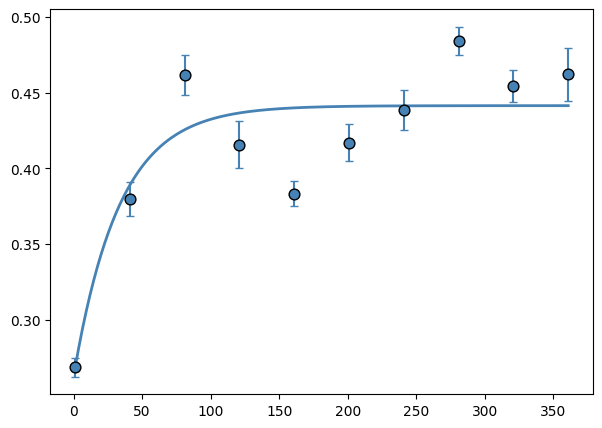

In [77]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"


py_avg = 5
max_circuit_depth = 400
delta_clifford = 40
number_sample = 30

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)

In [18]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
# interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]
interleaved_gates_to_test = ["X/2"]


for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)


--- Running Interleaved RB (X/2) ---


IRB (X/2):   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s015_RB_halfX_Q1_012


[fitrb] p=0.999977  a=1.0000  b=0.5372
[fitrb] σ(p)=1.06e-02  σ(a)=4.64e+02  σ(b)=4.64e+02

--- IRB ---
  p   = 99.997739 ± 1.056916 %
  EPC = 0.001131 ± 0.528458 %


(np.float64(1.130610394439735e-05),
 0.005284578590617893,
 np.float64(0.9999773877921112),
 0.010569157181235786,
 array([[ 1.11707084e-04,  4.90386323e+00, -4.90394555e+00],
        [ 4.90386323e+00,  2.15277075e+05, -2.15280682e+05],
        [-4.90394555e+00, -2.15280682e+05,  2.15284290e+05]]))

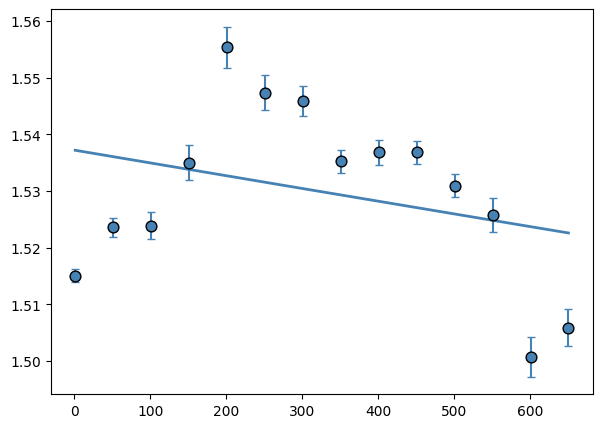

In [157]:
rb_exp_irb.plot(label="IRB")

[fitrb] p=0.999476  a=0.3988  b=-0.0291
[fitrb] σ(p)=1.92e-03  σ(a)=1.28e+00  σ(b)=1.29e+00

--- Reference ---
  p   = 99.947605 ± 0.191601 %
  EPC = 0.026198 ± 0.095801 %
[fitrb] p=0.992353  a=0.0577  b=0.3075
[fitrb] σ(p)=4.32e-03  σ(a)=1.21e-02  σ(b)=8.91e-03

--- IRB  X ---
  p   = 99.235295 ± 0.431679 %
  EPC = 0.382353 ± 0.215840 %


Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_21132\1880840758.py", line 36, in <module>
    fid_err  = rb_gate_fidelity_err(
NameError: name 'rb_gate_fidelity_err' is not defined


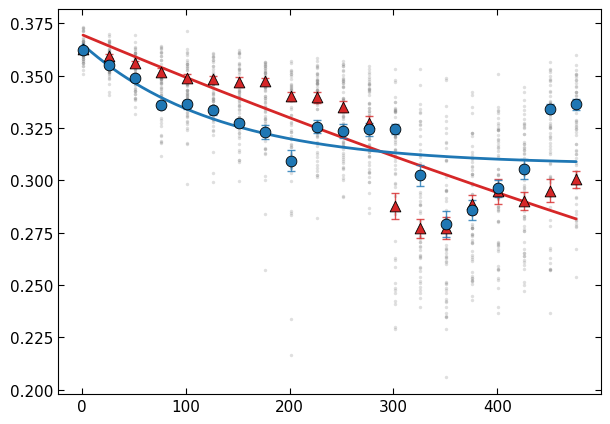

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from qick_workspace.tools.fitting import rb_gate_fidelity

REF_COLOR  = "tab:red"
IRB_COLORS = ["tab:blue", "tab:green", "tab:orange", "tab:purple", "tab:cyan"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.8)
ax.tick_params(colors="black", labelsize=11, direction="in",
               top=True, right=True, length=4)
ax.grid(False)

# ── Reference RB ─────────────────────────────────────────────────────────────
epc_ref, epc_err_ref, p_ref, p_err_ref, pCov_ref = rb_exp_ref.plot(
    label="Reference", color=REF_COLOR,
    marker="^", ax=ax, show_individual=True,
)

# ── Interleaved RB ────────────────────────────────────────────────────────────
gate_results = {}
for i, (rb_exp_irb, gate) in enumerate(
    zip(all_rb_results[1:], interleaved_gates_to_test)
):
    c = IRB_COLORS[i % len(IRB_COLORS)]
    epc_irb, epc_err_irb, p_irb, p_err_irb, pCov_irb = rb_exp_irb.plot(
        label=f"IRB  {gate}", color=c,
        marker="o", ax=ax, show_individual=True,
    )
    fidelity = rb_gate_fidelity(p_ref, p_irb, d=2)
    fid_err  = rb_gate_fidelity_err(
        p_ref, p_irb,
        cov_p_rb=pCov_ref[0, 0], cov_p_irb=pCov_irb[0, 0], d=2,
    )
    gate_results[gate] = (fidelity, fid_err, c)

# ── Annotation box ────────────────────────────────────────────────────────────
ann_lines = [f"EPC:  {epc_ref*100:.3f} ± {epc_err_ref*100:.3f} %"]
for gate, (fid, err, _) in gate_results.items():
    ann_lines.append(f"F({gate}): {fid*100:.4f} ± {err*100:.4f} %")
ann_text = "\n".join(ann_lines)

ax.text(0.97, 0.05, ann_text,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10, color="black",
        linespacing=1.7,
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="white",
                  edgecolor="black",
                  linewidth=0.8))

# ── Labels & legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Cliffords", fontsize=12)
ax.set_ylabel("Signal amplitude (a.u.)", fontsize=12)
ax.legend(fontsize=10, frameon=True,
          framealpha=1.0, edgecolor="black",
          loc="upper left")

fig.tight_layout()
plt.show()

# ── Console summary ───────────────────────────────────────────────────────────
print("\n=== Gate Fidelities ===")
for gate, (fid, err, _) in gate_results.items():
    print(f"  {gate:6s}  F = {fid*100:.4f} ± {err*100:.4f} %")

# Nodrag

In [ ]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"
run_cfg['relax_delay'] = 500
run_cfg['pi2_gain_ge']= 0.118189713318076


py_avg = 15
max_circuit_depth = 700
delta_clifford = 25
number_sample = 100

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
    interleaved_gate=None,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)
## Interleaved RB
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]
# interleaved_gates_to_test = ["X", "X/2"]


for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from qick_workspace.tools.fitting import rb_gate_fidelity

REF_COLOR  = "tab:red"
IRB_COLORS = ["tab:blue", "tab:green", "tab:orange", "tab:purple", "tab:cyan"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.8)
ax.tick_params(colors="black", labelsize=11, direction="in",
               top=True, right=True, length=4)
ax.grid(False)

# ── Reference RB ─────────────────────────────────────────────────────────────
epc_ref, epc_err_ref, p_ref, p_err_ref, pCov_ref = rb_exp_ref.plot(
    label="Reference", color=REF_COLOR,
    marker="^", ax=ax, show_individual=True,
)

# ── Interleaved RB ────────────────────────────────────────────────────────────
gate_results = {}
for i, (rb_exp_irb, gate) in enumerate(
    zip(all_rb_results[1:], interleaved_gates_to_test)
):
    c = IRB_COLORS[i % len(IRB_COLORS)]
    epc_irb, epc_err_irb, p_irb, p_err_irb, pCov_irb = rb_exp_irb.plot(
        label=f"IRB  {gate}", color=c,
        marker="o", ax=ax, show_individual=True,
    )
    fidelity = rb_gate_fidelity(p_ref, p_irb, d=2)
    fid_err  = rb_gate_fidelity_err(
        p_ref, p_irb,
        cov_p_rb=pCov_ref[0, 0], cov_p_irb=pCov_irb[0, 0], d=2,
    )
    gate_results[gate] = (fidelity, fid_err, c)

# ── Annotation box ────────────────────────────────────────────────────────────
ann_lines = [f"EPC:  {epc_ref*100:.3f} ± {epc_err_ref*100:.3f} %"]
for gate, (fid, err, _) in gate_results.items():
    ann_lines.append(f"F({gate}): {fid*100:.4f} ± {err*100:.4f} %")
ann_text = "\n".join(ann_lines)

ax.text(0.97, 0.05, ann_text,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10, color="black",
        linespacing=1.7,
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="white",
                  edgecolor="black",
                  linewidth=0.8))

# ── Labels & legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Cliffords", fontsize=12)
ax.set_ylabel("Signal amplitude (a.u.)", fontsize=12)
ax.legend(fontsize=10, frameon=True,
          framealpha=1.0, edgecolor="black",
          loc="upper left")

fig.tight_layout()
plt.show()

# ── Console summary ───────────────────────────────────────────────────────────
print("\n=== Gate Fidelities ===")
for gate, (fid, err, _) in gate_results.items():
    print(f"  {gate:6s}  F = {fid*100:.4f} ± {err*100:.4f} %")

# Drag


[DRAG Sum] Optimal α = 0.422481)


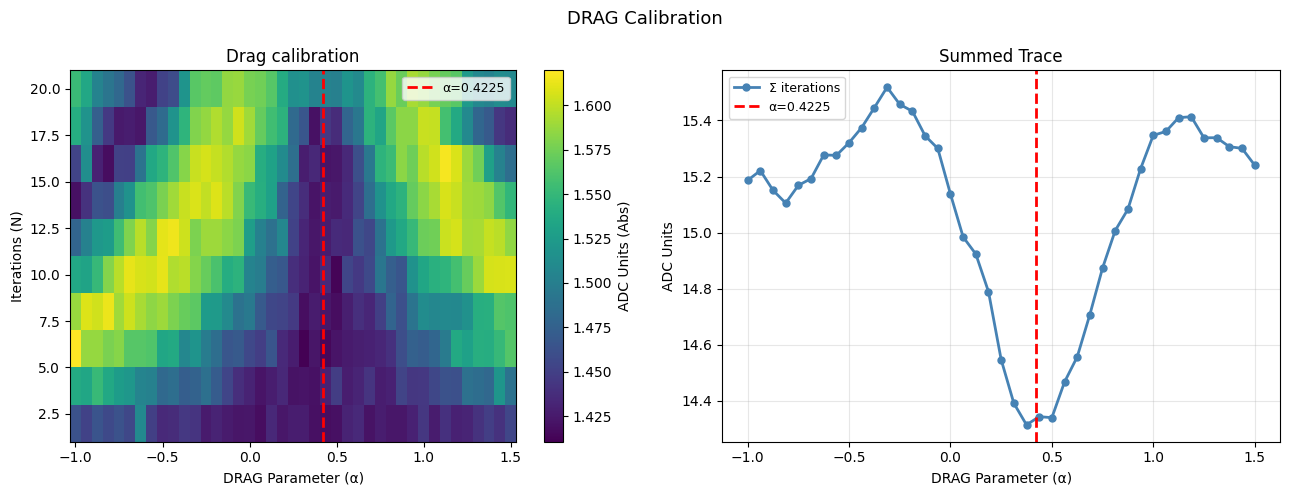

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s005a_drag_ge_Q1_013


In [20]:
from qick_workspace.newscrip.s005a_drag import DragCalibration

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        # Alpha
        ("alpha_start", -1),
        ("alpha_stop", 1.5),
        ("alpha_steps", 41), 
        # Iterationi
        ("iter_start", 2),
        ("iter_stop", 20),
        ("iter_step", 2),
    ]
)

drag_cal = DragCalibration(soc, soccfg, run_cfg)
fit_results = drag_cal.run(py_avg=5)


config_all.update("drag_alpha", fit_results['optimal_alpha'], q_index=qubit)

drag_cal.saveLabber(qubit, config_all=config_all)